# Budget Forcing

**Paper**: [s1: Simple test-time scaling](https://arxiv.org/abs/2501.19393)

**Authors**: Niklas Muennighoff, Zitong Yang, Weijia Shi, Xiang Lisa Li, Li Fei-Fei, Hannaneh Hajishirzi, Luke Zettlemoyer, Percy Liang, Emmanuel Candes, Tatsunori Hashimoto

Budget forcing controls the length of a reasoning model's thinking at test time. It caps the thinking phase at a token budget and can either shorten reasoning (force the closing think tag once the budget is hit) or lengthen it (append an extension such as "Wait" to prompt continued reasoning) before generating the final answer.

Budget forcing is a decoding driver built on the generic phased driver, with a plan consisting of a bounded thinking phase, optional extension rounds, a forced closing tag, and an unbounded answer phase.

The method assumes a reasoning model. The thinking-phase boundary is the model's own closing think tag. This means that the driver can only find the boundary if the model emits one, and on a non-reasoning model the tag never appears and the method degenerates to truncation plus an inserted tag.

## Method parameters

| parameter | type | description |
| --------- | ---- | ----------- |
| `max_thinking_tokens` | `int` | Token budget for each thinking segment |
| `extension_text` | `str` | Text appended to prolong reasoning |
| `num_extensions` | `int` | Number of extension rounds (0 disables) |
| `end_think` | `str` | The closing-think marker |

## Setup

If running this from a Google Colab notebook, uncomment the clone cell below. It is not necessary when running from a virtual environment where the package is already installed.

In [1]:
# !git clone https://github.com/IBM/steerability.git
# %cd Steerability

The following authentication steps may be necessary to access any gated models (after being granted access by Hugging Face). Uncomment the following if you need to log in to the Hugging Face Hub:

In [2]:
# !pip install -q python-dotenv
# from dotenv import load_dotenv
# import os

# load_dotenv()
# token = os.getenv("HUGGINGFACE_TOKEN")
# from huggingface_hub import login
# login(token=token)

## Example: varying a reasoning model's thinking budget

We use `deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B`, a small open reasoning model. Its chat template opens the thinking block (the prompt ends with `<think>`), and the model closes it by emitting `</think>` before writing its final answer. As a result, the driver's boundary marker occurs naturally in every generation. Following the model card we sample with temperature 0.6 and top-p 0.95 rather than decoding greedily, with a fixed seed to keep runs comparable.

The budget only affects answer quality on problems at the edge of the model's ability. On easy problems the model recovers from any truncation by re-deriving the solution inside the unbounded answer phase, and every budget then lands on the right answer. We therefore work on a Level 5 problem from MATH-500 (row `test/algebra/297.json` of the `HuggingFaceH4/MATH-500` subset of MATH), which asks for the product of the $y$-coordinates of all distinct solutions of $y=x^2-8$ and $y^2=-5x+44$. The derivation is long (square, assemble a quartic, factor it twice, apply the quadratic formula, and multiply four values including a conjugate pair). This means that partial reasoning does not degrade gracefully. The correct answer is 1736.

In [3]:
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

from steerability.algorithms.core.steering_pipeline import SteeringPipeline
from steerability.algorithms.output_control.budget_forcing.control import BudgetForcing
from steerability.evaluation.plotting import apply_plot_style, plot_sensitivity
from steerability.utils.answers import extract_numeric_answer
from steerability.utils.thinking import split_thinking
from steerability.utils.tokenization import count_tokens

MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
END_THINK = "</think>"
SAMPLING = {"do_sample": True, "temperature": 0.6, "top_p": 0.95}

# level 5 problem from MATH-500 (HuggingFaceH4/MATH-500, row test/algebra/297.json); the answer is 1736
PROBLEM = (
    "Find the product of the $y$-coordinates of all the distinct solutions $(x,y)$ "
    "for the two equations $y=x^2-8$ and $y^2=-5x+44$."
)
ANSWER = "1736"

The readouts below use three library helpers. `split_thinking` (from `steerability.utils.thinking`) splits a generation into its thinking span and final answer at the last closing tag, i.e., everything after the final tag (usually the forced one) counts as answer. `count_tokens` (from `steerability.utils.tokenization`) measures a span in tokens. `extract_numeric_answer` (from `steerability.utils.answers`) pulls the final answer out of its `\boxed{...}` wrapper or `Answer:` line and canonicalizes it, falling back to the last number in the stream.

### Baseline: the model's natural thinking length

We first look at how the model behaves unforced. We generate with a plain `model.generate` call and a generous token limit, then measure how long the model chooses to think. Per the model card's usage recommendation for math problems, the prompt asks for the final answer inside `\boxed{...}`, which is what the extractor anchors on.

In [4]:
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto", dtype="auto")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

prompt = f"{PROBLEM} Please reason step by step, and put your final answer within \\boxed{{}}."
chat = tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize=False,
    add_generation_prompt=True,
)
inputs = tokenizer(chat, return_tensors="pt", add_special_tokens=False).to(model.device)

set_seed(42)
baseline_ids = model.generate(**inputs, max_new_tokens=6144, pad_token_id=tokenizer.eos_token_id, **SAMPLING)
baseline_text = tokenizer.decode(baseline_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

thinking, answer = split_thinking(baseline_text)
print(f"thinking tokens: {count_tokens(tokenizer, thinking)}")
print(f"extracted answer: {extract_numeric_answer(baseline_text)} (target {ANSWER})")
print(f"\nend of answer: ...{answer[-350:]}")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

thinking tokens: 5926
extracted answer: 1736 (target 1736)
end of answer: ...e second equation:
\[
(x^2 - 8)^2 = -5x + 44
\]
Expanding and simplifying, we get:
\[
x^4 - 16x^2 + 64 = -5x + 44
\]
\[
x^4 - 16x^2 + 5x + 20 = 0
\]
We need to find the product of the y-coordinates, which are \(y_i = x_i^2 - 8\) for each root \(x_i\). This product is equivalent to the product of \((x_i^2 - 8)\) for all roots \(x_i\). 
Using Vi


Unforced, the model produces a long thinking span on this problem before committing to an answer, several times longer than the few hundred tokens it spends on grade-school word problems. That natural length is the reference point for the rest of the notebook, i.e., shortening cuts below it and extending pushes past where the model would have stopped. Note that at temperature 0.6 the natural length and even the final answer vary from run to run. For this reason, the sweep at the end averages over seeds.

### Shortening: capping the budget and forcing the tag

We cap thinking at `max_thinking_tokens=256` with no extensions. The plan is a thinking phase that stops at the closing tag or at 256 tokens (whichever comes first), the forced `</think>`, then the answer phase. At 256 tokens the model has not finished setting up the quartic. As a result, the thinking span below ends mid-derivation, where the tag was inserted. This is the "shorten" half of s1. From here on, each pipeline wraps the model loaded above (`SteeringPipeline` accepts a preloaded `model` and `tokenizer`), which avoids re-downloading between configurations.

In [5]:
budget_forcing = BudgetForcing(max_thinking_tokens=256, num_extensions=0, end_think=END_THINK)

pipeline = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[budget_forcing])
pipeline.steer()

set_seed(42)
output = pipeline.generate(
    input_ids=inputs["input_ids"].to(pipeline.model.device),
    max_new_tokens=768,
    pad_token_id=tokenizer.eos_token_id,
    **SAMPLING,
)
forced_text = tokenizer.decode(output[0], skip_special_tokens=True)
thinking, answer = split_thinking(forced_text)

print(f"thinking tokens: {count_tokens(tokenizer, thinking)}")
print(f"extracted answer: {extract_numeric_answer(forced_text)} (target {ANSWER})")
print(f"\nend of thinking span: ...{thinking[-160:]}")
print(f"\nend of answer: ...{answer[-350:]}")

thinking tokens: 256
extracted answer: 15 (target 1736)
end of thinking span: ...on becomes:
x⁴ - 16x² + 64 = -5x + 44
Hmm, I should bring all terms to one side to set it equal to zero. Let's subtract (-5x + 44) from both sides:
x⁴ - 16x²
end of answer: ...hat means (x + 1) is a factor of the quartic.
Now, let's perform polynomial division or use synthetic division to factor out (x + 1).
Let me use synthetic division with x = -1.
The coefficients of the quartic are 1 (x⁴), 0 (x³), -16 (x²), 5 (x), and 20 (constant).
So set up synthetic division:
-1 | 1   0   -16   5   20
    |     -1   1   15  -


The thinking span stops mid-sentence at the budget, and the model is forced to answer from whatever partial setup it has. The model compensates, i.e., the "answer" it writes after the forced tag attempts to re-derive the solution from scratch. On easy problems that recovery succeeds and hides the cut entirely, which is why easy problems show no effect from budget forcing. Here the compressed re-derivation has to complete a quartic factorization and a conjugate-pair product without room to check itself, and it typically makes an error along the way. As a result, the boxed answer usually comes out wrong. On this problem, cutting the budget below what the derivation needs costs accuracy.

### Extending: appending "Wait" to continue thinking

Extensions are the "lengthen" half of s1. Each extension round appends `Wait` to the stream and opens another bounded thinking segment. This means that a thought the budget would have cut short is prolonged instead. We keep the per-segment budget at 512 tokens to make the splice points easy to locate, i.e., the driver appends `Wait` right after tokens 512 and 1025 of the continuation.

In [6]:
budget_forcing = BudgetForcing(
    max_thinking_tokens=512,
    extension_text="Wait",
    num_extensions=2,
    end_think=END_THINK,
)

pipeline = SteeringPipeline(model=model, tokenizer=tokenizer, controls=[budget_forcing])
pipeline.steer()

set_seed(42)
output = pipeline.generate(
    input_ids=inputs["input_ids"].to(pipeline.model.device),
    max_new_tokens=2048,
    pad_token_id=tokenizer.eos_token_id,
    **SAMPLING,
)
extended_text = tokenizer.decode(output[0], skip_special_tokens=True)
thinking, answer = split_thinking(extended_text)
print(f"thinking tokens: {count_tokens(tokenizer, thinking)}")
print(f"extracted answer: {extract_numeric_answer(extended_text)} (target {ANSWER})")

wait_len = count_tokens(tokenizer, "Wait")
out_ids = output[0]
for i, splice_at in enumerate([512, 512 + wait_len + 512], start=1):
    window = tokenizer.decode(out_ids[splice_at - 20:splice_at + wait_len + 20], skip_special_tokens=True)
    print(f"\nsplice {i}: ...{window}...")

print(f"\nend of answer: ...{answer[-350:]}")

thinking tokens: 1537
extracted answer: 1736 (target 1736)
splice 1: ... - 16(-1)^2 + 5(-1) + 20 = Wait, no, x=-1:
(-1)^4 = 1
-16*(-1...
splice 2: ...
x=4:
64 -16 -60 +20 = 28Wait, 64 -16 is 48, 48 -60 is -...
end of answer: ...1)^2 - (5\sqrt{5})^2}{4} = \frac{1 - 125}{4} = \frac{-124}{4} = -31 \]
Thus, the product becomes:
\[ (-7) \times 8 \times (-31) = (-7) \times 8 \times (-31) \]
Calculating step-by-step:
First, multiply \( -7 \times 8 = -56 \)
Then, multiply \( -56 \times (-31) = 1736 \)
Therefore, the product of the \( y \)-coordinates is:
\[
\boxed{1736}
\]


Each splice shows the same pattern, i.e., the segment is cut mid-thought at its budget, `Wait` is appended, and the model continues the reasoning, often by re-examining what it had just concluded. The total thinking length is now set by the driver, not by when the model would have stopped on its own. Three bounded segments give the model roughly 1.5k thinking tokens here, which makes progress on the derivation but is often still short of what this problem requires. The sweep below quantifies this.

### The s1 curve: answer quality vs. thinking budget

Budget forcing is the mechanism behind s1's test-time scaling curves, where answer quality is a function of allotted thinking compute. On a problem past the model's comfortable range, the budget affects accuracy directly. The sweep below runs the same problem at three budgets with four sampled runs each, recording the thinking tokens used and the extracted answer for every run. The twelve runs share the one model already in memory and take a few minutes on a GPU.

In [7]:
budgets = [256, 1024, 4096]
num_trials = 4

records = []
for budget in budgets:
    sweep_pipeline = SteeringPipeline(
        model=model,
        tokenizer=tokenizer,
        controls=[BudgetForcing(max_thinking_tokens=budget, num_extensions=0, end_think=END_THINK)],
    )
    sweep_pipeline.steer()
    for seed in range(num_trials):
        set_seed(seed)
        output = sweep_pipeline.generate(
            input_ids=inputs["input_ids"].to(sweep_pipeline.model.device),
            max_new_tokens=max(budget, 768),
            pad_token_id=tokenizer.eos_token_id,
            **SAMPLING,
        )
        text = tokenizer.decode(output[0], skip_special_tokens=True)
        extracted = extract_numeric_answer(text)
        records.append({
            "budget": budget,
            "trial": seed,
            "thinking_tokens": count_tokens(tokenizer, split_thinking(text).thinking),
            "answer": extracted if extracted else "-",
            "accuracy": int(extracted == ANSWER),
        })

trials = pd.DataFrame(records)
trials.groupby("budget").agg(
    thinking_tokens=("thinking_tokens", "mean"),
    correct=("accuracy", "sum"),
    answers=("answer", ", ".join),
)

,thinking_tokens,correct,answers
budget,,,
256,256.00,0,"4, 8, -56, 1"
1024,1024.00,1,"-4, 1736, 5, -952"
4096,4347.25,4,"1736, 1736, 1736, 1736"


The per-budget accuracies trace the s1 curve for this problem, i.e., answer quality as a function of thinking compute. We plot them with `plot_sensitivity` from `steerability.evaluation.plotting`.

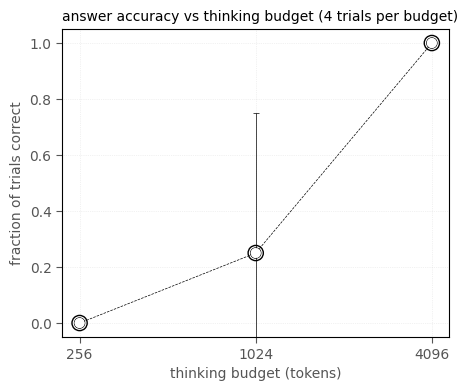

In [8]:
apply_plot_style()

summary = trials.groupby("budget", as_index=False)["accuracy"].agg(accuracy_mean="mean", accuracy_std="std")
ax = plot_sensitivity(
    summary,
    metric="accuracy",
    sweep_col="budget",
    metric_label="fraction of trials correct",
    sweep_label="thinking budget (tokens)",
    title=f"answer accuracy vs thinking budget ({num_trials} trials per budget)",
    ylim=(-0.05, 1.05),
)
ax.set_xscale("log", base=2)
ax.set_xticks(budgets)
ax.set_xticklabels([str(budget) for budget in budgets])
ax.tick_params(axis="x", which="minor", bottom=False)

The thinking-token column confirms that the budget sets the compute axis of the s1 curve, and the accuracy curve is the quality axis. At the smallest budget the model answers from a truncated setup, and the compressed recovery in the answer phase rarely completes the full derivation correctly. At the largest budget the derivation usually completes inside the thinking span and reaches 1736, with the middle budget in between. The exact counts move from run to run at temperature 0.6, but the upward trend with budget is stable. This is the s1 result, i.e., a single integer parameter trades decode compute against correctness. Note that this readout depends on the problem sitting at the edge of the model's ability. Rows the model finds easy produce a flat curve at the top regardless of budget (the answer phase absorbs the cut), and rows past its reach produce a flat curve at the bottom. Any MATH-500 Level 5 row with a long derivation and a short numeric answer can play the same role if this one falls outside that band on a different model variant.

### Mechanics

`BudgetForcing` is a preset of the generic phased driver. Its per-example plan is:

- `Generated(until="</think>", budget=max_thinking_tokens)`, the bounded thinking phase
- `num_extensions` repetitions of `Fixed(extension_text)` followed by another bounded `Generated`
- `Fixed("</think>")`, the forced closing tag
- `Generated()`, the unbounded answer phase

Phase boundaries are substring stops on the closing marker only. The opening `<think>` plays no role in the mechanics (here it lives in the prompt via the chat template). Since `Fixed` phases are plain token appends, when the model closes its thinking naturally within budget the forced tag is still appended and the stream carries the tag twice. Plans are built per example, and batched inputs are handled by looping over rows. Every `Generated` phase delegates to `model.generate` with the pipeline's composed stacks. This means that a step-level control (for example RAD) steers each phase, including the extensions.

### Takeaway

Budget forcing turns thinking length into an inference-time parameter, i.e., one integer trades answer quality against decode compute, and the "Wait" extension adds reasoning on demand without touching weights or prompts. Note that the method only applies to models that externalize their reasoning between think tags.

[phased_decoding.ipynb](generics/phased_decoding.ipynb) demonstrates the generic this preset is built on, including a thinking-intervention plan that splices steering text into the reasoning stream rather than bounding its length. See the [output control](https://ibm.github.io/steerability/concepts/controls/#output-control) section of the docs for the full family.